In [1]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
from astropy.io import fits
from sklearn.model_selection import train_test_split

I0000 00:00:1784228581.158176    3993 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1784228581.827501    3993 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1784228587.746374    3993 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
# Check if TensorFlow detects any GPUs
gpus = tf.config.list_physical_devices('GPU')

if gpus:
    print(f"Success! TensorFlow detected {len(gpus)} GPU(s): {gpus}")

    # Best Practice: Enable Memory Growth
    # This prevents TensorFlow from instantly reserving all your GPU VRAM,
    # which can crash your system or prevent other apps from running.
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("GPU memory growth enabled.")
    except RuntimeError as e:
        # Memory growth must be set before GPUs have been initialized
        print(e)
else:
    print("Warning: No GPU detected. TensorFlow will fall back to the CPU.")

Success! TensorFlow detected 1 GPU(s): [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
GPU memory growth enabled.


In [3]:

# ==========================================
# 1. DATA LOADING & PREPROCESSING
# ==========================================

def load_and_preprocess_ifu_data(data_dir, csv_path, filename_col, label_col):
    """
    Reads FITS files and labels, processes the IFU maps, and prepares them for TF.
    """
    # Load the CSV containing labels (0, 1, 2, 3)
    df = pd.read_csv(csv_path)

    images = []
    labels = []

    print("Reading FITS files and handling NaNs...")
    for index, row in df.iterrows():
        filename = row[filename_col]
        label = row[label_col]
        if label == -1:
            continue
        filepath = os.path.join(data_dir, filename)

        # Read the zeroth HDU
        with fits.open(filepath) as hdul:
            data = hdul[0].data  # Expected shape: (3, 69, 69)

        # Process each channel (flux, velocity, dispersion) independently
        for i in range(3):
            channel_data = data[i, :, :]

            # 1. Handle NaNs: Replace with the channel's mean
            mean_val = np.nanmean(channel_data)
            if np.isnan(mean_val):
                mean_val = 0.0  # Fallback if the entire channel is NaN
            channel_data[np.isnan(channel_data)] = mean_val
            data[i, :, :] = channel_data

        # Transpose from (Channels, Height, Width) to (Height, Width, Channels)
        data = np.transpose(data, (1, 2, 0)) # New shape: (69, 69, 3)

        images.append(data)
        labels.append(label)

    # Convert lists to NumPy arrays
    X = np.array(images, dtype=np.float32)
    y = np.array(labels, dtype=np.int32)

    print("Applying Global Robust Scaling to preserve physical scales...")
    for i in range(3):
        # Extract the channel across all images
        channel_all = X[:, :, :, i]

        # Calculate robust percentiles to handle extreme outliers safely
        p1 = np.percentile(channel_all, 1)
        p99 = np.percentile(channel_all, 99)

        # Scale to [-1, 1] globally based on these percentiles
        if p99 > p1:
            X[:, :, :, i] = 2.0 * ((X[:, :, :, i] - p1) / (p99 - p1)) - 1.0
            # Clip values that fall outside our robust percentile boundaries
            X[:, :, :, i] = np.clip(X[:, :, :, i], -1.0, 1.0)
        else:
            X[:, :, :, i] = 0.0

    return X, y

In [4]:

# ==========================================
# 2. MODEL ARCHITECTURE
# ==========================================

def build_ifu_model(input_shape=(69, 69, 3), num_classes=4):
    """
    Builds a CNN using DepthwiseConv2D for initial independent channel processing.
    """
    # L2 regularization factor to penalize memorization of the 40 Class 0 images
    l2_reg = tf.keras.regularizers.l2(1e-4)

    model = tf.keras.models.Sequential([
        tf.keras.layers.Input(shape=input_shape),
        tf.keras.layers.RandomFlip("horizontal_and_vertical"),

        # DEPTHWISE CONVOLUTION
        # Treats Flux, Velocity, and Dispersion independently.
        # depth_multiplier=8 means it creates 8 feature maps *per* input channel (24 total)
        tf.keras.layers.DepthwiseConv2D(
            kernel_size=(3, 3),
            depth_multiplier=8,
            activation='relu',
            padding='same',
            depthwise_regularizer=l2_reg
        ),
        tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),

        # STANDARD CONVOLUTIONS (With L2 regularization to prevent overfitting)
        tf.keras.layers.Conv2D(32, (3, 3), activation='relu', kernel_regularizer=l2_reg),
        tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),

        tf.keras.layers.Conv2D(64, (3, 3), activation='relu', kernel_regularizer=l2_reg),
        tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),

        # FLATTEN & CLASSIFY
        tf.keras.layers.GlobalAveragePooling2D(),
        tf.keras.layers.Dense(64, activation='relu', kernel_regularizer=l2_reg),
        tf.keras.layers.Dropout(0.4),  # Increased dropout to combat overfitting

        # 4 Classes -> Softmax output
        tf.keras.layers.Dense(num_classes, activation='softmax')
    ])

    # Compile the model
    # SparseCategoricalCrossentropy is used because labels are integers (0, 1, 2, 3)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [5]:
def create_balanced_dataset(X, y, batch_size=32, is_training=True):
    """
    Takes imbalanced arrays and returns a tf.data.Dataset that yields
    perfectly balanced batches (equal representation of all classes).
    """
    datasets = []
    unique_classes = np.unique(y)

    for c in unique_classes:
        # 1. Filter data for this specific class
        idx = np.where(y == c)[0]
        X_c = X[idx]
        y_c = y[idx]

        # 2. Create a dataset for this class
        ds = tf.data.Dataset.from_tensor_slices((X_c, y_c))

        # 3. Shuffle and repeat infinitely.
        # This is critical so the minority classes (e.g., class 0 with 50 items)
        # never run out during the epoch.
        if is_training:
            # Shuffle and repeat infinitely for training
            ds = ds.shuffle(buffer_size=len(idx)).repeat()
        else:
            # For validation, we want a stable stream that we can evaluate,
            # but we still want to repeat it so we can pull balanced batches cleanly
            ds = ds.shuffle(buffer_size=len(idx)).repeat()

        datasets.append(ds)

    # 4. Interleave the datasets uniformly
    # weights = [0.25, 0.25, 0.25, 0.25] means equal probability of pulling from any class
    weights = [1.0 / len(unique_classes)] * len(unique_classes)
    balanced_ds = tf.data.Dataset.sample_from_datasets(datasets, weights=weights)

    # 5. Batch the combined stream and prefetch for GPU efficiency
    balanced_ds = balanced_ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

    return balanced_ds

In [6]:

# ==========================================
# 3. EXECUTION PIPELINE
# ==========================================


# --- Configuration Variables ---
# UPDATE THESE PATHS AND COLUMN NAMES TO MATCH YOUR SETUP
DATA_DIRECTORY = "./VELOCITY_VDISP_FLUX MAPS"
CSV_FILE_PATH = "./files_list_and_axis.csv"
FILENAME_COLUMN_NAME = "filename"
LABEL_COLUMN_NAME = "type"

In [7]:

print("Loading and preprocessing data...")
X, y = load_and_preprocess_ifu_data(
    data_dir=DATA_DIRECTORY,
    csv_path=CSV_FILE_PATH,
    filename_col=FILENAME_COLUMN_NAME,
    label_col=LABEL_COLUMN_NAME
)


Loading and preprocessing data...
Reading FITS files and handling NaNs...
Applying Global Robust Scaling to preserve physical scales...


In [8]:

print(f"Data loaded! Shape of X: {X.shape}, Shape of y: {y.shape}")

Data loaded! Shape of X: (8978, 69, 69, 3), Shape of y: (8978,)


In [9]:
print('spheres', np.sum(y==0))
print('oblate', np.sum(y==1))
print('prolate', np.sum(y==2))
print('triaxial', np.sum(y==3))

spheres 58
oblate 7431
prolate 90
triaxial 1399


In [10]:


# Split into training and validation sets (80% train, 20% validation)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [11]:
# 3. Create the balanced Training Dataset
batch_size = 64
train_dataset = create_balanced_dataset(X_train, y_train, batch_size=batch_size, is_training=True)

I0000 00:00:1784228766.752610    3993 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3435 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


In [12]:
val_dataset_balanced = create_balanced_dataset(X_val, y_val, batch_size=batch_size, is_training=False)

# 4. Standard (Unbalanced) Validation Dataset for final, unbiased metrics
val_dataset_unbiased = tf.data.Dataset.from_tensor_slices((X_val, y_val))
val_dataset_unbiased = val_dataset_unbiased.batch(batch_size).prefetch(tf.data.AUTOTUNE)

In [13]:

print("Building model...")
model2 = build_ifu_model(input_shape=(69, 69, 3), num_classes=4)
model2.summary()

Building model...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip (RandomFlip)        │ (None, 69, 69, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ depthwise_conv2d                │ (None, 69, 69, 24)     │           240 │
│ (DepthwiseConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 34, 34, 24)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │         6,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,100 (117.58 KB)

 Trainable params: 30,100 (117.58 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:

print("Configuring Early Stopping...")
# Define the EarlyStopping callback
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',        # The metric to watch
    patience=8,                # How many epochs to wait for improvement before stopping
    restore_best_weights=True, # CRITICAL: Revert to the weights of the best epoch
    verbose=1                  # Prints a message when stopping is triggered
)

Configuring Early Stopping...


In [15]:
# 6. Calculate Steps Per Epoch
# Because our balanced training dataset repeats infinitely, `model.fit` won't
# know when an "epoch" is over. We have to tell it mathematically.
# A robust strategy: Define an epoch as the time it takes to see the majority
# class completely, supplemented by equal amounts of the minority classes.
max_class_count = max(np.bincount(y_train)) # e.g., ~6000 for class 1 in training
num_classes = len(np.unique(y_train))
steps_per_epoch = int((max_class_count * num_classes) / batch_size)

In [16]:
# Since we balanced the validation dataset, we must also specify validation steps
max_val_class_count = max(np.bincount(y_val))
validation_steps = int((max_val_class_count * num_classes) / batch_size)

In [17]:

print("Starting training with Early Stopping...")
# Train the model, passing the callback in a list
history = model2.fit(
        train_dataset,
        validation_data=val_dataset_balanced,
        epochs=50,
        steps_per_epoch=steps_per_epoch,
        validation_steps=validation_steps,
    )

Starting training with Early Stopping...
Epoch 1/50


I0000 00:00:1784228796.927378    4412 service.cc:153] XLA service 0x76cc840373b0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1784228796.927395    4412 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 3060 Laptop GPU, Compute Capability 8.6 (Driver: 13.0.0; Runtime: 12.8.0; Toolkit: 12.5.0; DNN: 9.19.0)
I0000 00:00:1784228796.962602    4412 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1784228797.090832    4412 cuda_dnn.cc:461] Loaded cuDNN version 91900
I0000 00:00:1784228797.126990    4412 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2452__.47
I0000 00:00:1784228797.477160    4412 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set i

 18/371 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.3009 - loss: 1.3831 

I0000 00:00:1784228802.884439    4412 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


371/371 ━━━━━━━━━━━━━━━━━━━━ 12s 13ms/step - accuracy: 0.4760 - loss: 1.1683 - val_accuracy: 0.4956 - val_loss: 1.2266
Epoch 2/50
371/371 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.5425 - loss: 1.0448 - val_accuracy: 0.4794 - val_loss: 1.2486
Epoch 3/50
371/371 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.5716 - loss: 0.9725 - val_accuracy: 0.5155 - val_loss: 1.2937
Epoch 4/50
371/371 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.6116 - loss: 0.9075 - val_accuracy: 0.5110 - val_loss: 1.3063
Epoch 5/50
371/371 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.6555 - loss: 0.8381 - val_accuracy: 0.5413 - val_loss: 1.3197
Epoch 6/50
371/371 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.6827 - loss: 0.7788 - val_accuracy: 0.4771 - val_loss: 1.5855
Epoch 7/50
371/371 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.7172 - loss: 0.7164 - val_accuracy: 0.5617 - val_loss: 1.5757
Epoch 8/50
371/371 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.7477 - loss: 0.6549 - val_accuracy: 0.59

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

In [19]:

# ==========================================
# 4. PLOTTING TRAINING CURVES
# ==========================================

def plot_training_history(history):
    """
    Plots the training and validation accuracy and loss curves.
    """
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(1, len(acc) + 1)

    plt.figure(figsize=(14, 5))

    # Plot Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy', marker='o')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy', marker='o')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend(loc='lower right')
    plt.grid(True, linestyle='--', alpha=0.7)

    # Plot Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss', marker='o')
    plt.plot(epochs_range, val_loss, label='Validation Loss', marker='o')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend(loc='upper right')
    plt.grid(True, linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()

In [20]:

# ==========================================
# 5. DETAILED EVALUATION
# ==========================================

def evaluate_model_performance(model, X_val, y_val, class_names=None):
    """
    Evaluates the model on validation data and plots a confusion matrix.
    """
    print("\n--- Final Model Evaluation ---")
    loss, accuracy = model.evaluate(X_val, y_val, verbose=0)
    print(f"Validation Loss: {loss:.4f}")
    print(f"Validation Accuracy: {accuracy:.4f}")

    # Get predictions
    # model.predict returns an array of probabilities for the 4 classes
    y_pred_probs = model.predict(X_val)
    # Convert probabilities to actual class labels (0, 1, 2, 3)
    y_pred = np.argmax(y_pred_probs, axis=1)

    # Print Classification Report (Precision, Recall, F1-Score per class)
    print("\nClassification Report:")
    print(classification_report(y_val, y_pred, target_names=class_names))

    # Plot Confusion Matrix
    cm = confusion_matrix(y_val, y_pred)
    plt.figure(figsize=(8, 6))

    # Using seaborn for a heatmap representation
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names if class_names else [0, 1, 2, 3],
                yticklabels=class_names if class_names else [0, 1, 2, 3])

    plt.title('Confusion Matrix')
    plt.xlabel('Predicted Class')
    plt.ylabel('True Class')
    plt.show()

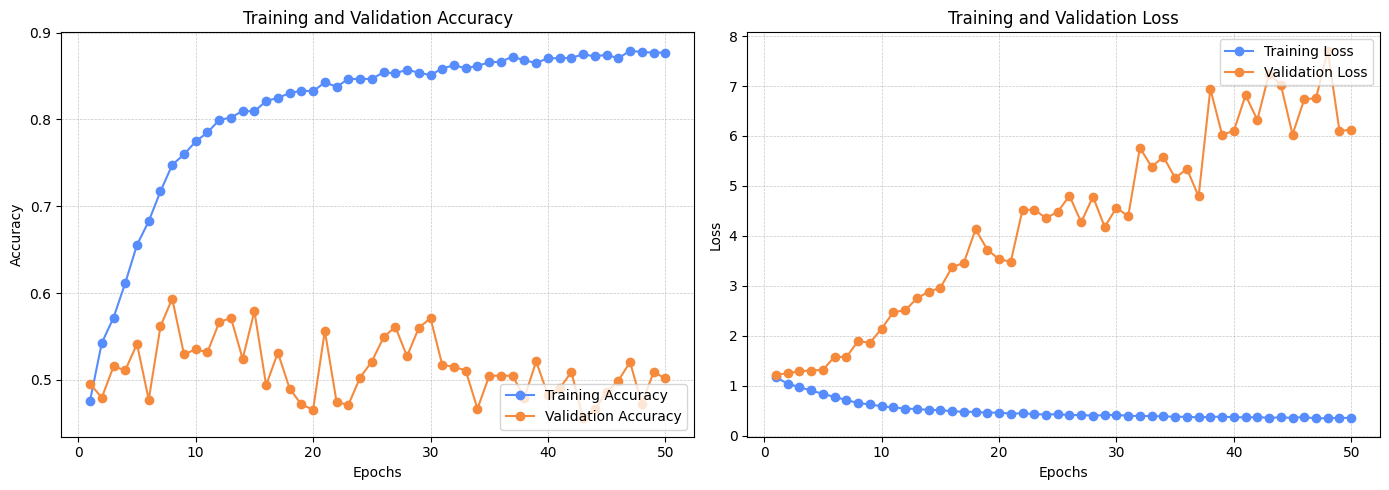

In [21]:

# ==========================================
# ADD THIS TO YOUR EXECUTION PIPELINE
# ==========================================
# (Run this right after 'history = model.fit(...)')

# Plot the curves
plot_training_history(history)

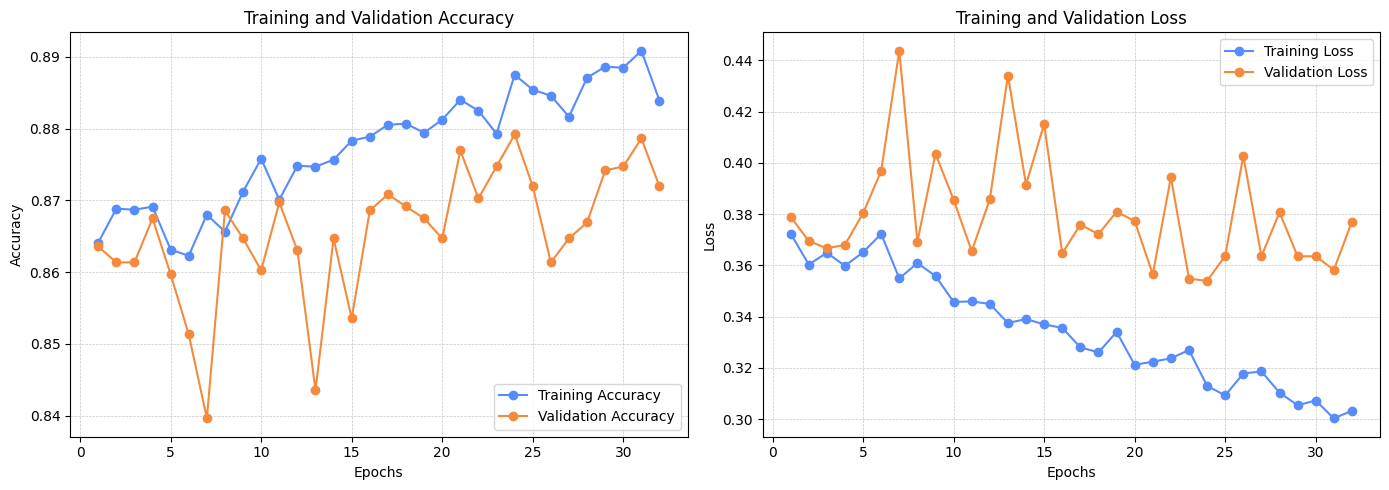

In [40]:

# ==========================================
# ADD THIS TO YOUR EXECUTION PIPELINE
# ==========================================
# (Run this right after 'history = model.fit(...)')

# Plot the curves
plot_training_history(history)

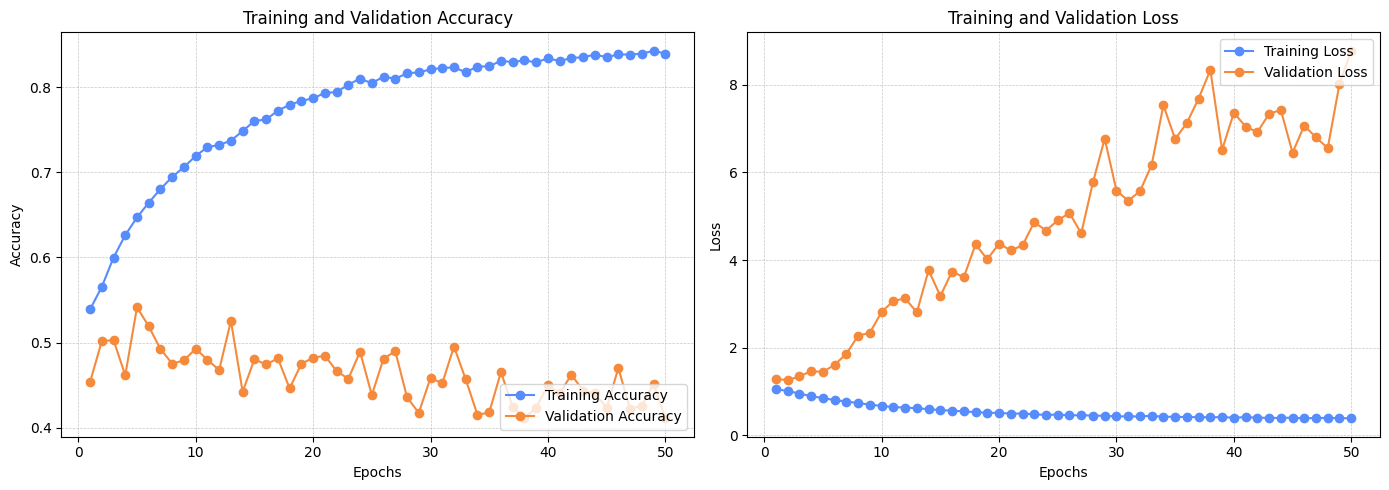

In [60]:

# ==========================================
# ADD THIS TO YOUR EXECUTION PIPELINE
# ==========================================
# (Run this right after 'history = model.fit(...)')

# Plot the curves
plot_training_history(history)


--- Final Model Evaluation ---


I0000 00:00:1784229050.098534    4411 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1784229050.475840    7145 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_4', 84 bytes spill stores, 84 bytes spill loads



Validation Loss: 0.7710
Validation Accuracy: 0.7840
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step

Classification Report:
              precision    recall  f1-score   support

    Sperical       0.10      0.33      0.15        12
      Oblate       0.94      0.81      0.87      1486
     Prolate       0.10      0.17      0.13        18
    Triaxial       0.45      0.70      0.55       280

    accuracy                           0.78      1796
   macro avg       0.40      0.50      0.42      1796
weighted avg       0.85      0.78      0.81      1796



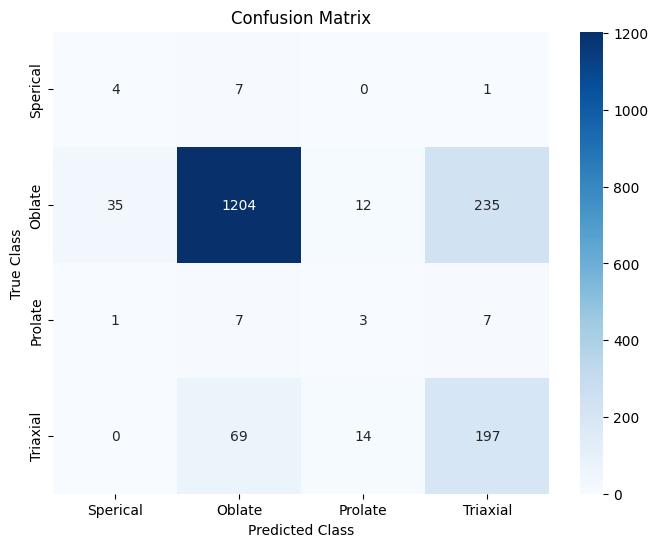

In [22]:

# Evaluate and show confusion matrix
# (e.g., ['Spiral', 'Elliptical', 'Merger', 'Irregular'])
evaluate_model_performance(model2, X_val, y_val, class_names=['Sperical', 'Oblate', 'Prolate', 'Triaxial'])


--- Final Model Evaluation ---
Validation Loss: 0.3539
Validation Accuracy: 0.8792
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step

Classification Report:
              precision    recall  f1-score   support

    Sperical       0.00      0.00      0.00        12
      Oblate       0.89      0.98      0.93      1486
     Prolate       0.00      0.00      0.00        18
    Triaxial       0.76      0.45      0.57       280

    accuracy                           0.88      1796
   macro avg       0.41      0.36      0.37      1796
weighted avg       0.86      0.88      0.86      1796



/home/astrolander/.generalvenv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/astrolander/.generalvenv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/astrolander/.generalvenv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()}

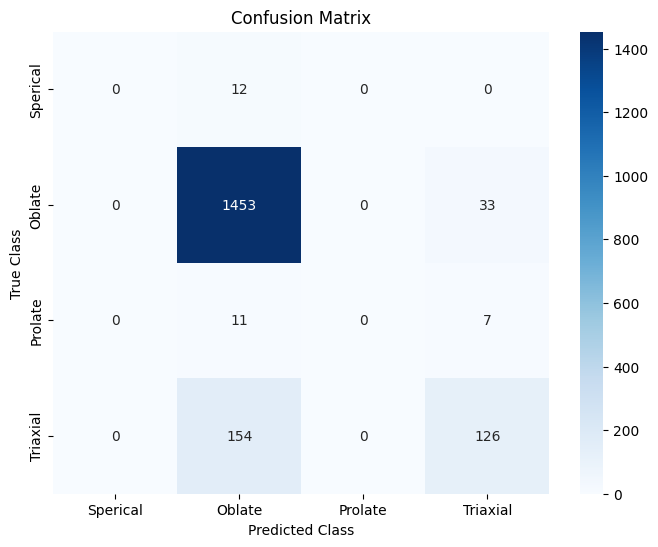

In [41]:

# Evaluate and show confusion matrix
# (e.g., ['Spiral', 'Elliptical', 'Merger', 'Irregular'])
evaluate_model_performance(model2, X_val, y_val, class_names=['Sperical', 'Oblate', 'Prolate', 'Triaxial'])